In [4]:
# %pip install imblearn
import pandas as pd
import matplotlib.pyplot as plt
import warnings
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer
from sklearn.svm  import SVC
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import  cross_val_score

warnings.filterwarnings('ignore')
df = pd.read_csv('../../Datasets/fromclass/HR_comma_sep.csv')
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)



In [5]:
df_shuffled.drop_duplicates(inplace=True)
X = df_shuffled.drop(['left'],axis=1)
y = df_shuffled['left']



numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns

numeric_pipeline = Pipeline([
  ("imputer", SimpleImputer(strategy="median")),
  ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
  ("imputer", SimpleImputer(strategy="most_frequent")),
  ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
  ("num", numeric_pipeline, numerical_cols),
  ("cat", categorical_pipeline, categorical_cols),
])


pipeline = {
    "LogReg": Pipeline([
        ("preprocess", preprocessor),
        ("model", LogisticRegression(max_iter=100))
    ]),
    "SVC": Pipeline([
        ("preprocess", preprocessor),
        ("model", SVC())
    ]),
    "RF": Pipeline([
        ("preprocess", preprocessor),
        ("model", RandomForestClassifier(random_state=42))
    ])
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)
for name, pipeline in pipeline.items():
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring="accuracy")
    print(f"{name}: mean={scores.mean():.4f}  std={scores.std():.4f}")


LogReg: mean=0.8338  std=0.0058
SVC: mean=0.9680  std=0.0058
RF: mean=0.9830  std=0.0031


accuracy Score : 0.9886047804335742
F1 Score : 0.9652836579170194
-**-**--**-**--**-**--**-**--**-**--**-**--**-**--**-**-
Confuision metrix
[[2987    0]
 [  41  570]]
-**-**--**-**--**-**--**-**--**-**--**-**--**-**--**-**-
              precision    recall  f1-score   support

    Remained       0.99      1.00      0.99      2987
        Left       1.00      0.93      0.97       611

    accuracy                           0.99      3598
   macro avg       0.99      0.97      0.98      3598
weighted avg       0.99      0.99      0.99      3598



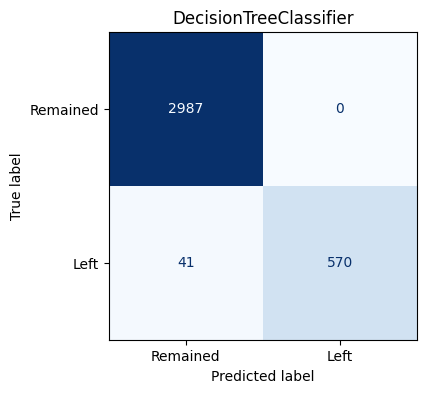

In [6]:





X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

mapping = {'high':3, 'medium':2, 'low':1}
X_train['salary'] = X_train['salary'].map(mapping).fillna(0)
X_test['salary']  = X_test['salary'].map(mapping).fillna(0)

pipeline.fit(X, y)
prediction = pipeline.predict(X_test)



accuracy_log = accuracy_score(y_test,prediction)
f1score_log = f1_score(y_test,prediction)
confMetrix_log = confusion_matrix(y_test,prediction)

print(f'accuracy Score : {accuracy_log}')
print(f'F1 Score : {f1score_log}')
print('-**-**-'*8)
print(f'Confuision metrix')
print(confMetrix_log)
print('-**-**-'*8)
print(classification_report(y_test, prediction, target_names=['Remained', 'Left']))


cm = confusion_matrix(y_test, prediction)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Remained', 'Left'])

fig, ax = plt.subplots(figsize=(4, 4))
disp.plot(cmap='Blues', ax=ax, colorbar=False)
ax.set_title(f"DecisionTreeClassifier")
plt. show()
print("\n")





